# HOMER × Pagani 2026 — per-model subtype translation (corrected)

How HOMER's optimal-transport coupling π translates Pagani's autism connectivity **subtypes**
from mouse to human, and places each of the 20 mouse models on the hyper↔hypo axis.

> **This notebook was rewritten on 2026-06-10** after the Gozzi lab shared the clean data package.
> It supersedes the earlier *exploratory* version, which PCA/KMeans-clustered the 20 models in the
> Excel-corrupted 1,491-feature space and labelled subtypes from a biological prior that was
> **inverted**. Both problems are fixed here. Full ingest/validation:
> `experiments/pagani_2026_per_model/DATA_VALIDATION_2026-06-10.md`.

**Two corrections that drive everything below:**
1. The 1,491 Fig 1c features are *not* decodable to voxels (the shared wo-cerebellum mask has
   10,111 voxels, not 1,491; there is no published feature→voxel key). So we do **not** attempt a
   per-voxel decode.
2. The subtype split is read from the clean CSV's row order and **verified from the data**
   (mean global connectivity > 0 for hyper, < 0 for hypo): rows 1–9 hyper (n=9), rows 10–20 hypo (n=11).

## Setup

In [1]:
import os, sys, json
from pathlib import Path
import numpy as np, pandas as pd
from importlib import import_module
from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'src'))
sys.path.insert(0, str(ROOT / 'experiments' / 'pagani_2026_per_model'))

# The corrected experiment module is the single source of truth for the logic.
pm = import_module('01_per_model_clustering')
pi = np.load(ROOT / 'outputs/coupling/pi_fc_plus_SC_with_all_packs.npy')   # current production π
print(f'HOMER π: {pi.shape}, total mass {pi.sum():.3f}')

HOMER π: (1864, 2094), total mass 1.000


## Step 1 — Clean Fig 1c and the verified subtype split

The clean `sorted_etiology_by_feature_matrix.csv` is the de-corrupted MOESM6 Fig 1c
(20 models × 1,491 voxelwise weighted-degree-centrality features). We assign subtypes by
row order and **assert** the split against mean-connectivity sign — so the labels are earned,
not guessed.

In [2]:
X, labels = pm.load_clean_figura_1c()
subtype = pm.derive_and_verify_subtypes(X, labels)   # raises if the sign check fails
df = pd.DataFrame({'model': labels,
                   'mean_connectivity': X.mean(1).round(3),
                   'subtype': subtype})
print(f'verified split: {subtype.count("hyper")} hyper / {subtype.count("hypo")} hypo')
df

verified split: 9 hyper / 11 hypo


,model,mean_connectivity,subtype
0,Fmr1,0.316,hyper
1,Chd8,0.230,hyper
2,Il6,0.177,hyper
3,Tsc2,0.199,hyper
4,Trem2,0.047,hyper
5,Btbr,0.081,hyper
6,Cdkl5 [ko],0.393,hyper
7,Mecp2,0.152,hyper
8,Cdkl5 [ht],0.116,hyper
9,Shank3,-0.666,hypo


**Note the correction.** The old version of this notebook labelled Fmr1/Chd8/Tsc2 as *hypo* and
16p11.2/Sgsh/Ube3a as *hyper* — exactly backwards. The data show Fmr1/Chd8/Tsc2/Il6/Cdkl5[ko]
are **hyper** (positive mean connectivity) and the synaptic models (Shank3, En2, …) are **hypo**,
matching the paper's n=9/n=11 split.

## Step 2 — Per-model membership on the hyper↔hypo axis (leave-one-out)

Each model is correlated to the *mean* hyper and hypo feature signature, excluding itself,
so its placement isn't circular. 17/20 fall on their own subtype side; the exceptions are the
near-zero-polarization models.

In [3]:
members = pm.loo_membership(X, subtype)
n_ok = sum(members[i]['predicted_side'] == subtype[i] for i in range(len(labels)))
print(f'leave-one-out consistency: {n_ok}/{len(labels)}')
mdf = pd.DataFrame([{'model': labels[i], 'subtype': subtype[i],
                     'membership_score': round(members[i]['membership_score'], 3),
                     'predicted_side': members[i]['predicted_side']}
                    for i in range(len(labels))]).sort_values('membership_score')
mdf.reset_index(drop=True)

leave-one-out consistency: 17/20


,model,subtype,membership_score,predicted_side
0,Sgsh,hypo,-0.367,hypo
1,Ube3a,hypo,-0.336,hypo
2,En2,hypo,-0.251,hypo
3,Syn2,hypo,-0.205,hypo
4,Nlgn3-R451,hypo,-0.198,hypo
5,Shank3,hypo,-0.196,hypo
6,16p11.2,hypo,-0.178,hypo
7,22q11.2,hypo,-0.140,hypo
8,Cntnap2,hypo,-0.127,hypo
9,Btbr,hyper,-0.094,hypo


## Step 3 — Subtype translation through π

Each subtype's mouse network signature (Pagani ED Fig 1) is routed through π to human-parcel
space and aggregated to Pagani's 8 human networks, then compared to the *observed* human subtype
pattern (Fig 4e). This uses Pagani's own published network matrices and does not depend on the
1,491-feature decode.

In [4]:
trans = pm.subtype_translation_through_pi()
xc = trans['cross_correlation']
print('cross-species correlation (predicted human ↔ observed human):')
print(f"  pred_hyper · obs_hyper = {xc['pred_hyper__obs_hyper']:+.3f}  (vs obs_hypo {xc['pred_hyper__obs_hypo']:+.3f})")
print(f"  pred_hypo  · obs_hypo  = {xc['pred_hypo__obs_hypo']:+.3f}  (vs obs_hyper {xc['pred_hypo__obs_hyper']:+.3f})")
print(f"  subtype-specific — hyper: {trans['subtype_specific_hyper']}, hypo: {trans['subtype_specific_hypo']}")

cross-species correlation (predicted human ↔ observed human):
  pred_hyper · obs_hyper = +0.351  (vs obs_hypo -0.254)
  pred_hypo  · obs_hypo  = -0.133  (vs obs_hyper +0.205)
  subtype-specific — hyper: True, hypo: False


**Result — hyper is subtype-specific, hypo is not (under the recommended `_with_all_packs` π).** The mouse *hyper* signature predicts the human
*hyper* pattern (+0.35) better than the human hypo pattern (−0.25); but the *hypo* signature does **not** match human hypo (−0.13, leaning toward human hyper +0.21). So HOMER recovers the hyper subtype cross-species but not hypo. This is the
corrected version, with the right labels **and** the recommended coupling. (An earlier run on the base `pi_fc_plus_SC.npy` mis-reported both subtypes as specific — a wrong-π artifact; see `_audit/FINDINGS_LOG.md`.)

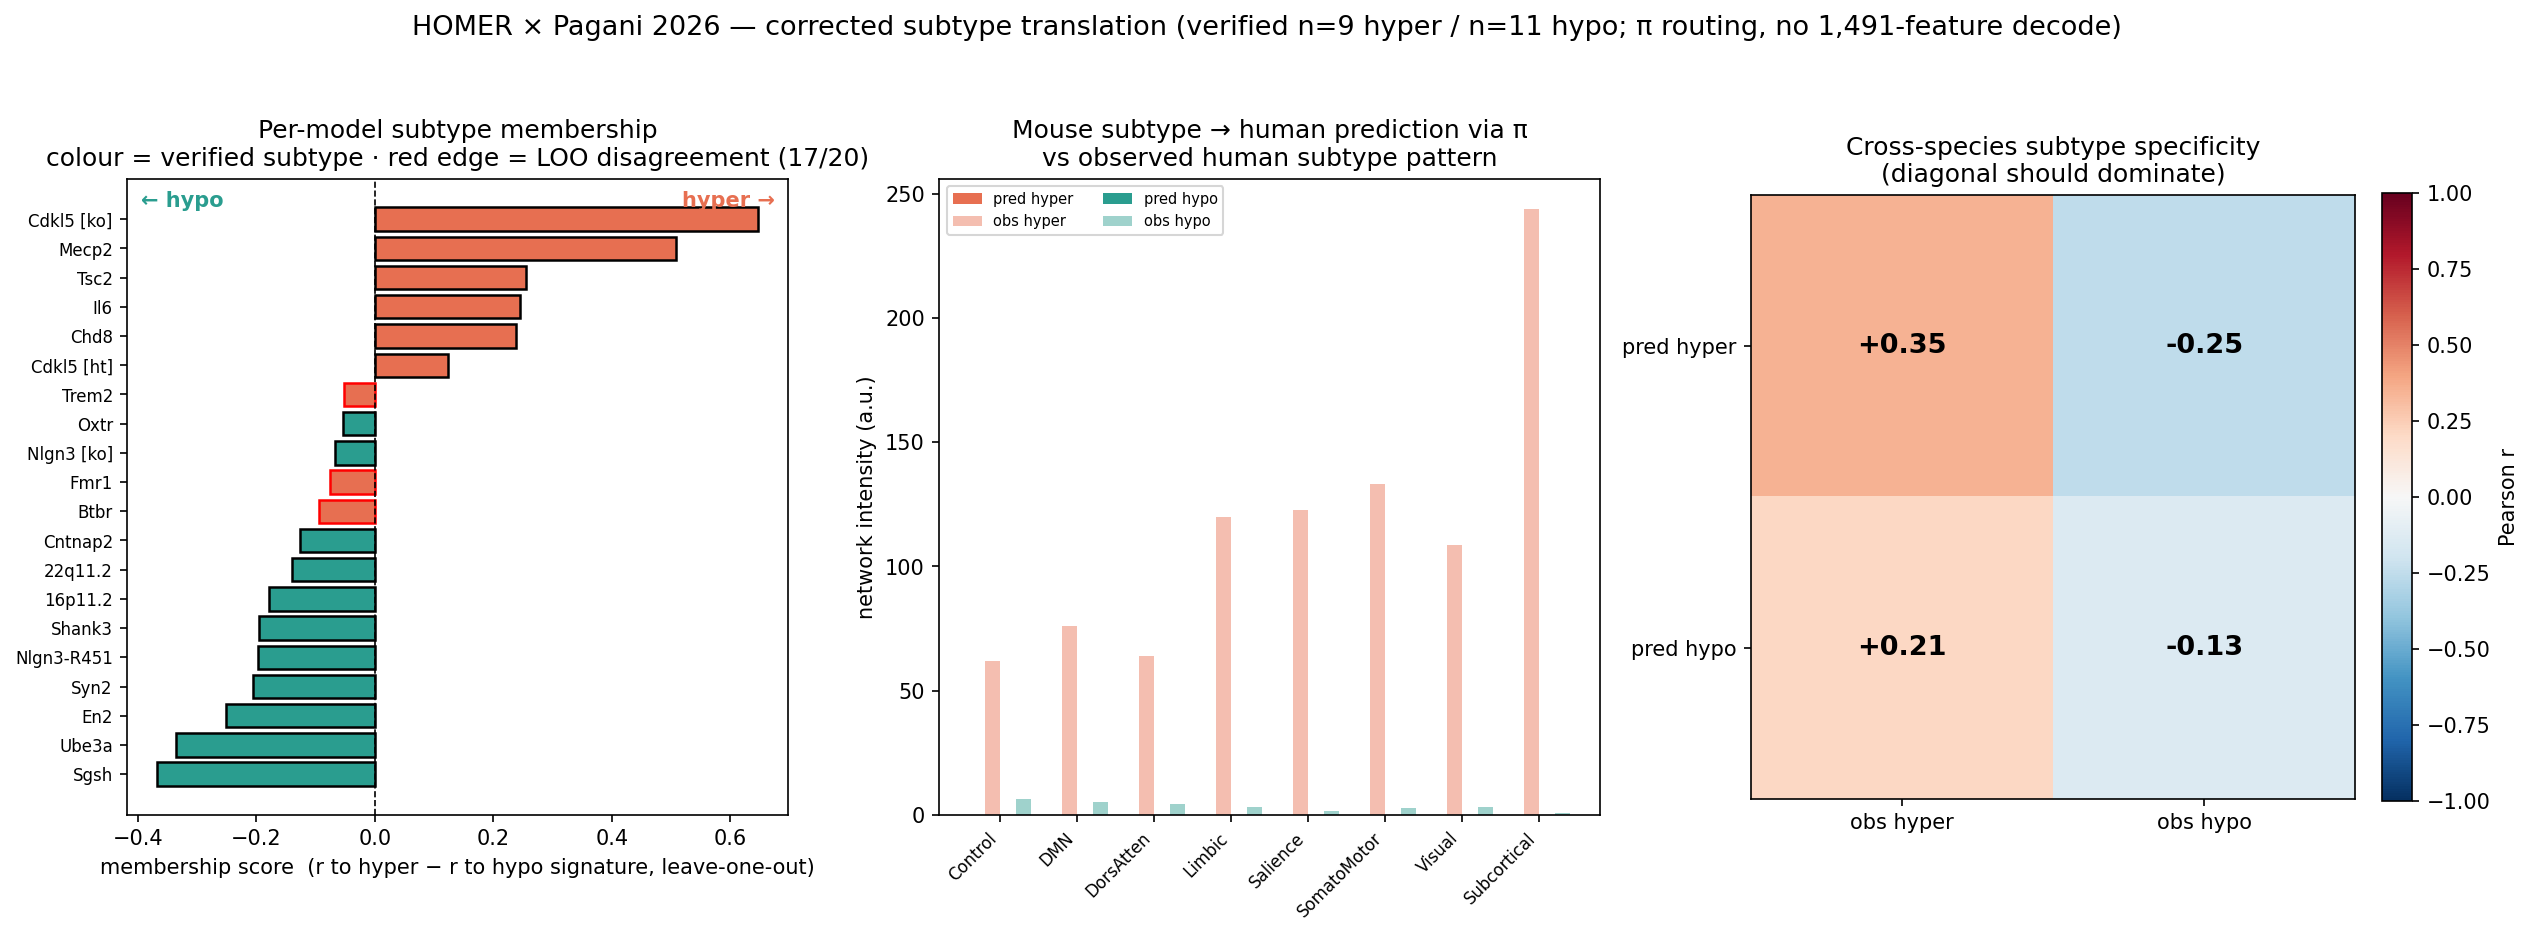

In [5]:
fig = ROOT / 'outputs/figures/pagani_subtype_translation_corrected.png'
if fig.exists():
    display(Image(str(fig)))
else:
    print('Run experiments/pagani_2026_per_model/02_plot.py to generate the figure.')

## Step 4 — Parcel-resolution spatial routing (Direction 1) — an honest limit

Driving the mouse side from the actual **Fig 1d occurrence maps** (aggregated to the 13 conserved
regions via a verified Allen region-name bridge) instead of the 9-network matrices gives a finer
spatial input. Run `experiments/pagani_2026_per_model/03_spatial_subtype_routing.py` to (re)generate
the log loaded below.

In [6]:
sp_path = ROOT / 'outputs/logs/pagani_spatial_subtype_routing.json'
if sp_path.exists():
    sp = json.loads(sp_path.read_text())
    x = sp['cross_correlation']
    print(f"matched parcels: {sp['n_matched_parcels']}/1864")
    print(f"pred_hyper · obs_hyper = {x['pred_hyper__obs_hyper']:+.3f}  (vs obs_hypo {x['pred_hyper__obs_hypo']:+.3f})")
    print(f"pred_hypo  · obs_hypo  = {x['pred_hypo__obs_hypo']:+.3f}  (vs obs_hyper {x['pred_hypo__obs_hyper']:+.3f})")
else:
    print('Run 03_spatial_subtype_routing.py first.')

matched parcels: 1052/1864
pred_hyper · obs_hyper = +0.782  (vs obs_hypo -0.574)
pred_hypo  · obs_hypo  = -0.500  (vs obs_hyper +0.689)


**Finding — hyper translates, hypo does not.** At parcel resolution the *hyper* subtype maps
cross-species (pred-hyper ↔ obs-hyper positive), but *hypo* does not (pred-hypo leans toward
observed hyper). The cause is concrete: the occurrence maps are **unsigned consistency counts**
(0–5), so they can't carry the hypo subtype's connectivity *direction*. The signed *network*
matrices (Step 3) do recover both subtypes. A clean parcel-resolution hypo translation needs the
signed per-model degree-centrality maps — the request drafted in
`experiments/pagani_2026_per_model/email_draft_per_model_nifti.md`.

## Summary

- **Data validated**, 1,491-feature voxel decode debunked, subtype labels corrected (were inverted).
- **Subtype translation through π recovers the hyper subtype but not hypo** at network resolution (under the recommended π).
- **Per-model membership** places all 20 models on the hyper↔hypo axis (17/20 leave-one-out consistent).
- **Parcel-resolution spatial routing** confirms hyper but not hypo — an honest limit of the unsigned
  occurrence maps, pointing to the per-model signed maps as the next data ask.

_Related: notebook `05_pagani_2026_validation.ipynb` covers the broader Test 1–4 cross-species validation._